# Finetuning RF-DETR for Player Detection and Tracking

Finetuning RF-DETR, following reference: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-finetune-rf-detr-on-detection-dataset.ipynb#scrollTo=PtOufRspVekp

In [1]:
!pip -V

pip 25.3 from /Users/rjunw/Desktop/dev/nba2nba/.venv/lib/python3.11/site-packages/pip (python 3.11)


In [ ]:
# !pip install -q rfdetr==1.2.1 supervision==0.26.1 roboflow tensorboard mlflow tqdm

## Imports and Installs

In [28]:
# sys deps
import os
from pathlib import Path
from dotenv import load_dotenv

# data deps
from roboflow import Roboflow
from PIL import Image

# model deps
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES

# tracking deps
import mlflow
from tqdm import tqdm

# env vars
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

# model vars
LOAD_MODEL = True
RF_DETR_MEDIUM_CHECKPOINT = "../models/rf_detr_od/checkpoint_best_total.pth"

# mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

## Data Processing

In [6]:
CACHE_DIR = Path("../data/.cache/")
CACHE_DIR.mkdir(parents=True,exist_ok=True)

train_data_path = CACHE_DIR.joinpath("bball_od/")
print('NBA PLAYER DETECTION DATA:', train_data_path)

# check if we have files in the directory and use them if we do
if list(train_data_path.glob("*")):
    print(f"Data cached, using {train_data_path}")

# otherwise download from Roboflow
else:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("roboflow-jvuqo").project("basketball-player-detection-2")
    version = project.version(20)
    dataset = version.download("coco", location=str(train_data_path))

NBA PLAYER DETECTION DATA: ../data/.cache/bball_od
Data cached, using ../data/.cache/bball_od


## Pre-Trained Model Inference

Let's make sure RF-DETR runs by loading the pre-trained model and running inference on one of our training images.

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


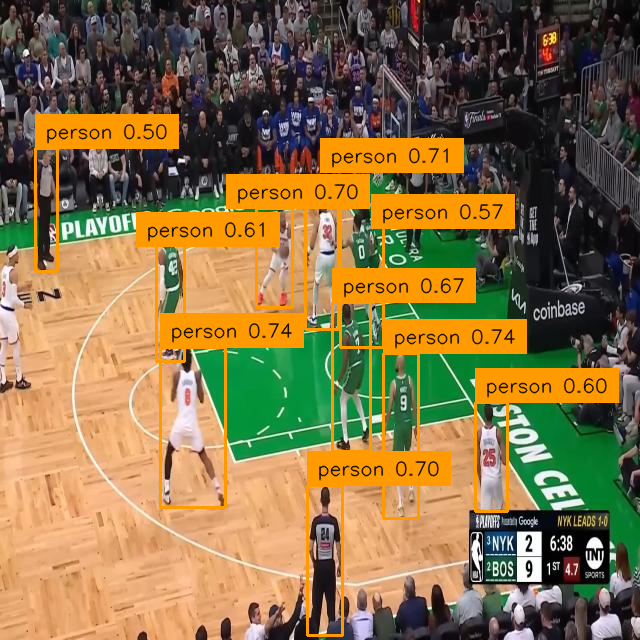

In [9]:
test_image = Image.open("../data/.cache/bball_od/train/boston-celtics-new-york-knicks-game-2-jump-shots_mp4-0000_jpg.rf.89a91895352faa1b1f6378d14326ba03.jpg")

# multi-resolution (multiples of 32) training lets you tradeoff resolution and latency
model = RFDETRMedium(resolution = 640)

# compile model so it runs faster on inference
model.optimize_for_inference()

# no NMS needed in RF-DETR
# outputs will be [(x_bl, y_bl, x_tr, y_tr, class_id, confidence)]
detections = model.predict(test_image, threshold = 0.5)

# just plotting schtuff
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=test_image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=test_image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = test_image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image.thumbnail((800, 800))
annotated_image

Notice, we are only classifying the players as *person*. This is because this pre-trained model is optimized on COCO, not the NBA domain.

## NBA Object Detection Finetuning

RF-DETR requires COCO-format datasets to fine-tune.

Fine-tuned in Colab because I'm on Apple Silicon.

In [ ]:
train_config = {
    "epochs": 10,
    "batch_size": 32,
    "grad_accum_steps": 1
}

if LOAD_MODEL and Path(RF_DETR_MEDIUM_CHECKPOINT).is_file():
    print("Loading model from checkpoint weights")
    model = RFDETRMedium(pretrain_weights="../models/rf_detr_od/checkpoint_best_total.pth")
else:
    print("Finetuning model from COCO pre-trained weights")

    with mlflow.start_run(run_name="rf_detr_od_finetuning"):
        mlflow.log_params(train_config)
        mlflow.log_artifact("../models/rf_detr_od/rf-detr-medium.pth")
        model = RFDETRMedium(pretrain_weights="../models/rf_detr_od/rf-detr-medium.pth")
        model.train(
            dataset_dir=str(train_data_path),
            **train_config
        )

        mlflow.log_artifact("output/metrics_plot.png")
    mlflow.end_run()

Loading model from checkpoint weights
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 5 classes, but your model has 90 classes
reinitializing detection head with 5 classes


Loading pretrain weights


## Evaluating Fine-Tuned RF-DETR

In [ ]:
# set mlflow experiment for tracking
mlflow.set_experiment("rf_detr_od_evaluation")

2025/11/24 22:19:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/24 22:19:55 INFO mlflow.store.db.utils: Updating database tables
2025-11-24 22:19:55 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-24 22:19:55 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-24 22:19:55 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-24 22:19:55 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025/11/24 22:19:55 INFO mlflow.tracking.fluent: Experiment with name 'rf_detr_od_evaluation' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/rjunw/Desktop/dev/nba2nba/notebooks/mlruns/1', creation_time=1764040795653, experiment_id='1', last_update_time=1764040795653, lifecycle_stage='active', name='rf_detr_od_evaluation', tags={}>

In [24]:
# compile model
model.optimize_for_inference()

# load test dataset
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [50]:
with mlflow.start_run(run_name="inf_optimized_test_eval"):
    mlflow.set_tag("train_dataset", "https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/dataset/19")
    mlflow.set_tag("test_dataset", "https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/dataset/20")
    mlflow.set_tag("model", "rf_detr_medium")
    mlflow.set_tag("checkpoint", RF_DETR_MEDIUM_CHECKPOINT)
    
    mlflow.log_params(train_config)
    
    # get predictions and respective targets
    targets = []
    predictions = []

    for path, image, annotations in tqdm(ds):
        image = Image.open(path)
        detections = model.predict(image, threshold=0)

        targets.append(annotations)
        predictions.append(detections)

    map_metric = MeanAveragePrecision()
    map_result = map_metric.update(predictions, targets).compute()
    print(map_result)
    
    mlflow.log_metric("mAP_IoU_0.50:0.95", map_result.map50_95.mean())
    mlflow.log_metric("mAP_IoU_0.50", map_result.map50.mean())
    mlflow.log_metric("mAP_IoU_0.75", map_result.map75.mean())
    mlflow.log_metric("mAP_IoU_0.50:0.95_small", map_result.small_objects.map50_95.mean())
    mlflow.log_metric("mAP_IoU_0.50:0.95_medium", map_result.medium_objects.map50_95.mean())
    mlflow.log_metric("mAP_IoU_0.50:0.95_large", map_result.large_objects.map50_95.mean())

mlflow.end_run()


100%|██████████| 169/169 [00:15<00:00, 10.86it/s]


Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.561
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.910
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.584
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.309
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.750
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.835


## Inference

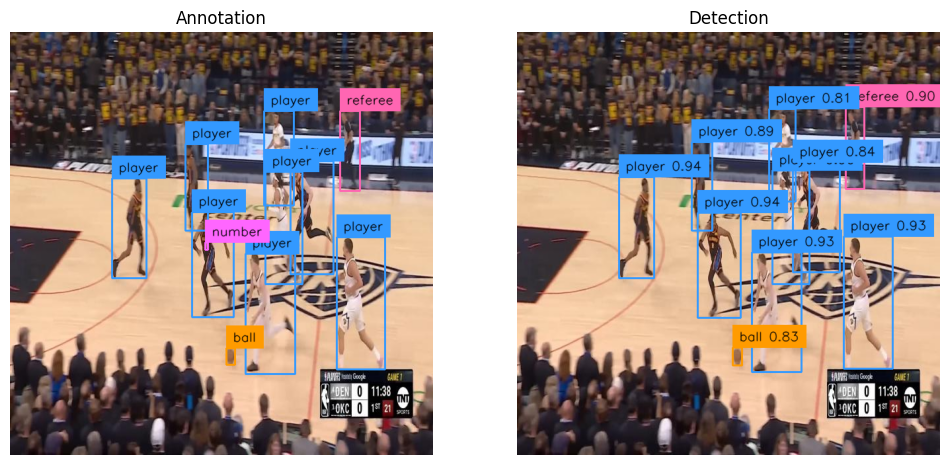

In [51]:
path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])